# Datenvorbereitung mit Python
## Vom Rohdatensatz zum trainierbaren Modell

### Ausgangssituation

Wir möchten zwei Möwenarten automatisch unterscheiden:

- **Lachmöwe**
- **Silbermöwe**

Dafür steht uns ein Datensatz mit Bildern und daraus extrahierten Merkmalen zur Verfügung.

Die eigentliche Frage lautet aber nicht:

> „Welchen Machine-Learning-Algorithmus verwenden wir?“

Sondern zunächst:

> **Sind unsere Daten überhaupt so vorbereitet, dass ein Modell daraus lernen kann?**

Genau dieser Frage gehen wir heute nach.

## Lernziele
Ziele für heute wären
- **Daten beurteilen:** typische Qualitätsprobleme in einem Datensatz erkennen und einordnen,
- **Daten vorbereiten:** geeignete Schritte wie Filtern und One-Hot-Encoding begründen,
- **Daten aufteilen:** erklären, warum Trainings- und Testdaten getrennt werden,
- **Modelle bewerten:** die Leistung eines Klassifikationsmodells anhand geeigneter Kennzahlen interpretieren.

### Leitfrage der Veranstaltung

> **Wie wird aus einem Rohdatensatz ein Datensatz, aus dem ein Modell zuverlässig lernen kann?**

## 2. Datensatzstruktur und Einlesen der Daten (5-15 min)
Der Datensatz liegt in einer praxisnahen Projektstruktur:

```text
moewen_ml_demo/
├── images/
├── moewen_raw.csv
```

Diese Struktur ist typisch für reale ML-Projekte: tabellarische Daten plus zusätzliche Artefakte wie Bilder und Metadaten.

Die CSV-Datei enthält Beobachtungen (Zeilen) und Merkmale (Spalten)

Mit Pandas laden wir diese Daten als DataFrame. Der DataFrame ist unsere zentrale Arbeitsstruktur für Analyse, Bereinigung und Modellierung.

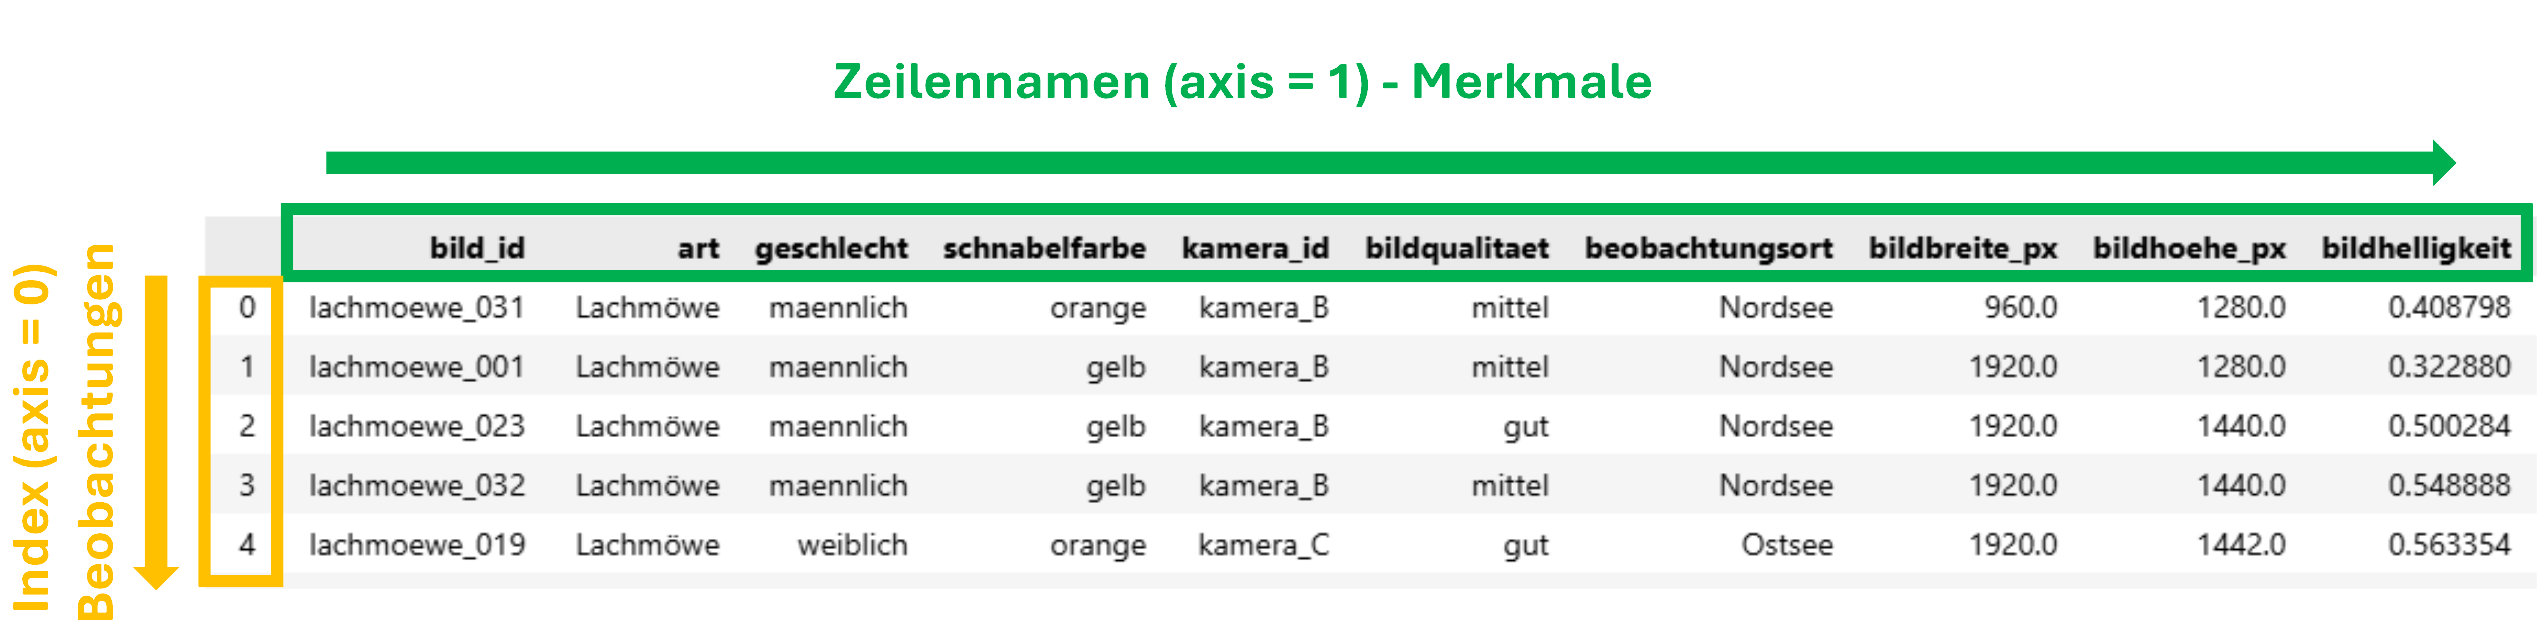

**Weiterführende Informationen:**
1. https://pandas.pydata.org/docs/user_guide/index.html

In [6]:
# Schritt 1: Bibliotheken importieren und den Datensatzpfad festlegen
import pandas as pd
from pathlib import Path

CSV_PFAD = Path(r"D:/PythonCode/DL_Stuff/moewen_ml_demo/moewen_raw.csv")

# Schritt 2: CSV-Datei einlesen
# Jede Zeile entspricht einer Beobachtung, jede Spalte ein Merkmal oder eine Zielvariable.
df = pd.read_csv(CSV_PFAD)

df.info()  # Informationen über den Datensatz anzeigen

#visualisieren des Datensatzes im Datafrane
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bild_id            80 non-null     object 
 1   art                78 non-null     object 
 2   geschlecht         74 non-null     object 
 3   schnabelfarbe      77 non-null     object 
 4   kamera_id          80 non-null     object 
 5   bildqualitaet      80 non-null     object 
 6   beobachtungsort    80 non-null     object 
 7   bildbreite_px      80 non-null     float64
 8   bildhoehe_px       80 non-null     float64
 9   bildhelligkeit     80 non-null     float64
 10  fluegellaenge_mm   80 non-null     float64
 11  schnabellaenge_mm  75 non-null     float64
 12  kopfflaeche_px     80 non-null     float64
 13  fluegelflaeche_px  80 non-null     float64
 14  kopfhelligkeit     80 non-null     float64
 15  schnabelfarbwert   80 non-null     float64
dtypes: float64(9), object(7)
mem

,bild_id,art,geschlecht,schnabelfarbe,kamera_id,bildqualitaet,beobachtungsort,bildbreite_px,bildhoehe_px,bildhelligkeit,fluegellaenge_mm,schnabellaenge_mm,kopfflaeche_px,fluegelflaeche_px,kopfhelligkeit,schnabelfarbwert
0,lachmoewe_031,Lachmöwe,maennlich,orange,kamera_B,mittel,Nordsee,960.0,1280.0,0.408798,109.432548,38.047213,12383.334295,17558.106957,0.824765,0.557122
1,lachmoewe_001,Lachmöwe,maennlich,gelb,kamera_B,mittel,Nordsee,1920.0,1280.0,0.322880,100.535833,40.357953,10294.011852,21739.515833,0.710287,0.685528
2,lachmoewe_023,Lachmöwe,maennlich,gelb,kamera_A,gut,Nordsee,1920.0,1440.0,0.500284,104.260955,38.168390,7364.337552,21214.402686,0.695631,0.516467
3,lachmoewe_032,Lachmöwe,maennlich,gelb,kamera_A,mittel,Nordsee,1920.0,1440.0,0.548888,98.781738,39.812531,8924.788492,19934.192567,0.875786,0.656504
4,lachmoewe_019,Lachmöwe,weiblich,orange,kamera_C,gut,Ostsee,1920.0,1442.0,0.563354,101.804203,37.494764,11829.322872,20379.421558,0.769641,0.560387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,lachmoewe_021,Lachmöwe,maennlich,orange,kamera_A,gut,Binnenland,1920.0,1440.0,0.516420,105.852899,39.082515,12404.412520,23737.215573,0.863618,0.561459
76,silbermoewe_021,Silbermöwe,weiblich,gelb,kamera_B,gut,Binnenland,1280.0,853.0,0.373668,114.104525,40.461851,12097.164891,34260.865054,0.686066,0.880147
77,silbermoewe_032,Silbermöwe,weiblich,orange,kamera_B,mittel,Ostsee,1920.0,1187.0,0.518035,132.514544,NaN,12821.695725,27351.748563,0.612522,0.727639
78,lachmoewe_015,Lachmöwe,weiblich,orange,kamera_A,gut,Ostsee,1920.0,1280.0,0.481236,178.000000,38.638338,10713.947919,28164.547689,0.779119,0.697929


## Was fällt auf?

Schauen wir uns die Ergebnisse nicht nur technisch, sondern fachlich an.

- Welche Spalten könnten für die Klassifikation relevant sein?
- Welche Spalten sind eher Metadaten?
- Gibt es bereits Merkmale, bei denen wir genauer hinschauen sollten?

> **Exploration bedeutet nicht nur, Daten auszugeben – sondern aus den Daten Fragen abzuleiten.**

## 3. Labels prüfen und Datenkonsistenz sichern
Bevor wir Features modellieren, prüfen wir die Zielvariable und die Label-Konsistenz.

- Passen Bild-ID, Merkmale und Label logisch zusammen?



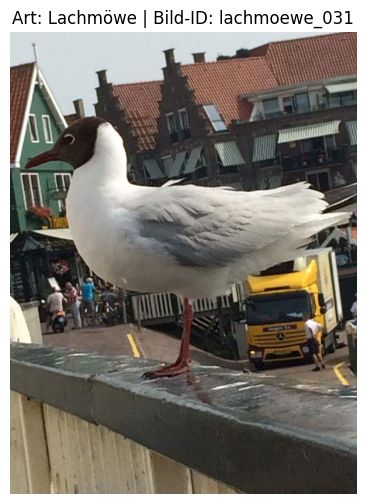

In [7]:
# Bildladen und Anzeige: Wir wollen prüfen, ob die CSV und die Bilddateien zusammenpassen.
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

BILD_PFAD = Path(r"D:/PythonCode/DL_Stuff/moewen_ml_demo/images")

# Hilfsfunktion: Ein Bild kann verschiedene Dateiendungen haben.
# Deshalb suchen wir systematisch nach .jpg, .jpeg oder .png.
def finde_bildpfad(bild_id: str):
    for suffix in [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]:
        kandidat = BILD_PFAD / f"{bild_id}{suffix}"
        if kandidat.exists():
            return kandidat
    raise FileNotFoundError(f"Kein Bild für Bild-ID {bild_id} gefunden.")

# Erstes Bild aus dem Datensatz laden
bild_id = df["bild_id"].iloc[0]
art = df["art"].iloc[0]
image_path = finde_bildpfad(bild_id)

image = Image.open(image_path)
plt.figure(figsize=(6, 6))
plt.title(f"Art: {art} | Bild-ID: {bild_id}")
plt.imshow(image)
plt.axis("off")
plt.show()

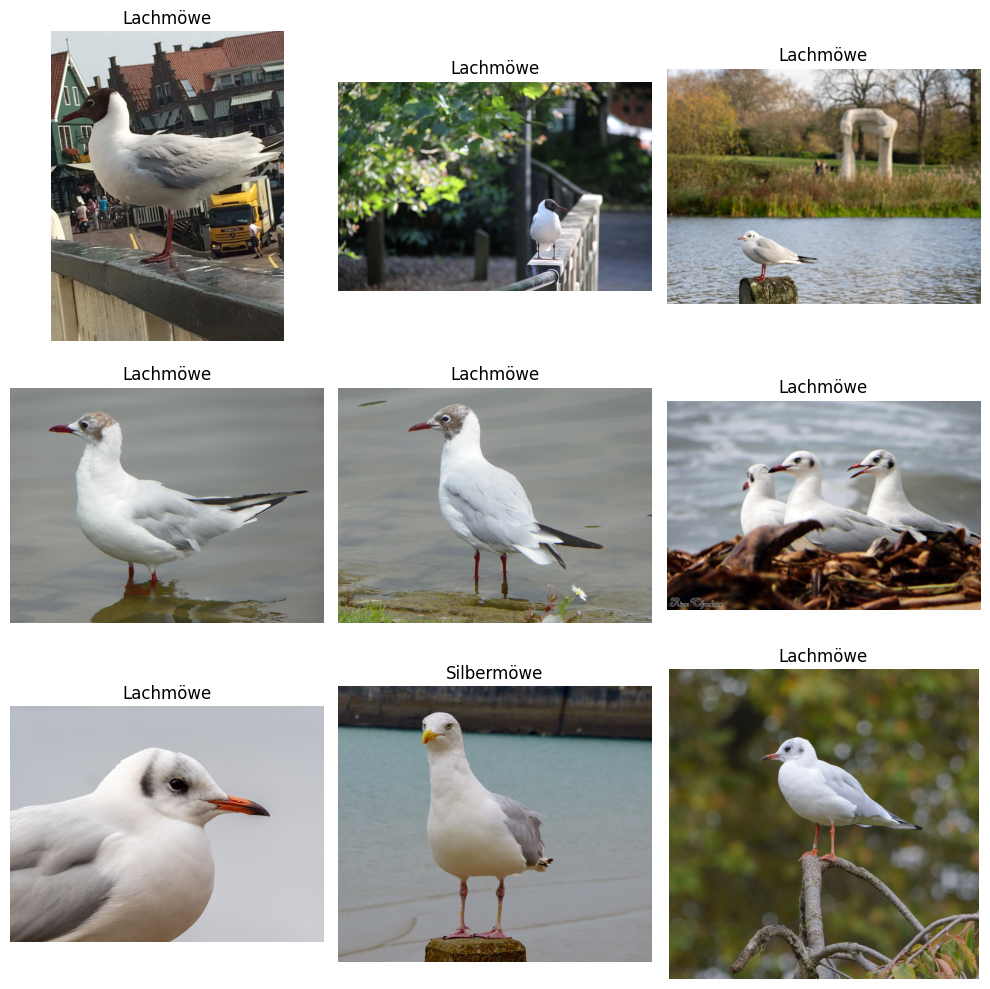

In [8]:
# Mehrere Beispielbilder anzeigen, damit wir visuell einen Eindruck der Daten bekommen.
# Das ist wichtig, weil wir nicht nur zahlenbasierte Merkmale, sondern auch Bildinformationen betrachten.
import matplotlib.pyplot as plt
from PIL import Image

N = 3
fig, axes = plt.subplots(N, N, figsize=(10, 10))

for i in range(N):
    for j in range(N):
        idx = i * N + j
        bild_id = df["bild_id"].iloc[idx]
        art = df["art"].iloc[idx]
        image_path = finde_bildpfad(bild_id)
        image = Image.open(image_path)

        axes[i, j].imshow(image)
        axes[i, j].set_title(f"{art}")
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

# Was fällt auf, wenn wir die Daten visuell inspizieren ?

1. Nicht konsistente Bildausschnitte. In einigen Bildern ist die Möwe zentraler Bestandteil des Bildes, in anderen nimmt die Szene einen großen Bereich ein.
2. Unterschiedliche Bildgrößen. Die verwendeten Kameras scheinen unterschiedliche Auflösungen zu haben.
3. Auf einigen Bildern sind Möwen nur zum Teil zu sehen auf anderen sind mehr als eine Möwe zu sehen.

*Was sind Schlussfolgerungen aus diesen Beobachtungen ?*

# 4. Visualisierung der Verteilungen unser Quantitativen Merkmale

> Quantitative Merkmale: Quantitative Merkmale sind Zahlen, die eine Größenbedeutung haben und auf einer Skala definiert werden können wie Alter, Gewicht, Kosten, ...


*Was sind die Quantitativen Merkmale in unserem Datensatz ?*

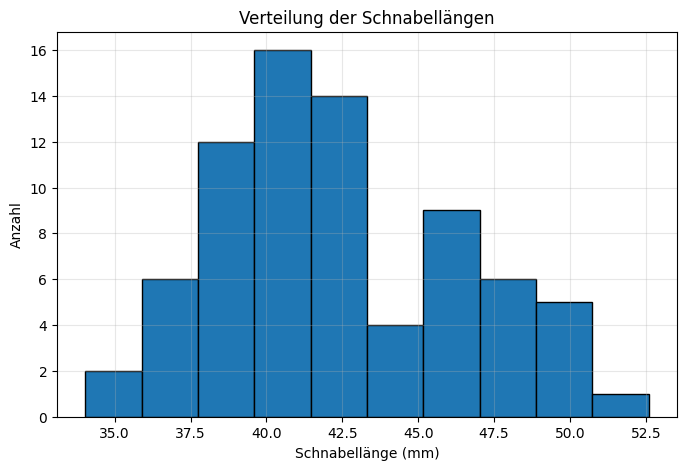

Minimum: 34.03 mm
Maximum: 52.60 mm
Mittelwert: 42.46 mm
Standardabweichung: 4.04 mm


In [9]:
# Verteilung der Schnabellänge
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df["schnabellaenge_mm"].hist(bins=10, edgecolor="black")
plt.title("Verteilung der Schnabellängen")
plt.xlabel("Schnabellänge (mm)")
plt.ylabel("Anzahl")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Minimum: {df['schnabellaenge_mm'].min():.2f} mm")
print(f"Maximum: {df['schnabellaenge_mm'].max():.2f} mm")
print(f"Mittelwert: {df['schnabellaenge_mm'].mean():.2f} mm")
print(f"Standardabweichung: {df['schnabellaenge_mm'].std():.2f} mm")

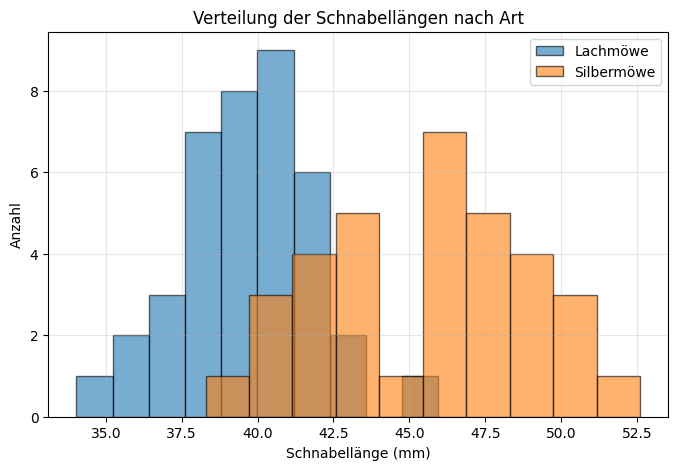

In [10]:
# Vergleich der Schnabellänge nach Art
import matplotlib.pyplot as plt

lachmoewe = df[df["art"] == "Lachmöwe"]["schnabellaenge_mm"]
silbermoewe = df[df["art"] == "Silbermöwe"]["schnabellaenge_mm"]

plt.figure(figsize=(8, 5))
plt.hist(lachmoewe, bins=10, alpha=0.6, label="Lachmöwe", edgecolor="black")
plt.hist(silbermoewe, bins=10, alpha=0.6, label="Silbermöwe", edgecolor="black")
plt.title("Verteilung der Schnabellängen nach Art")
plt.xlabel("Schnabellänge (mm)")
plt.ylabel("Anzahl")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

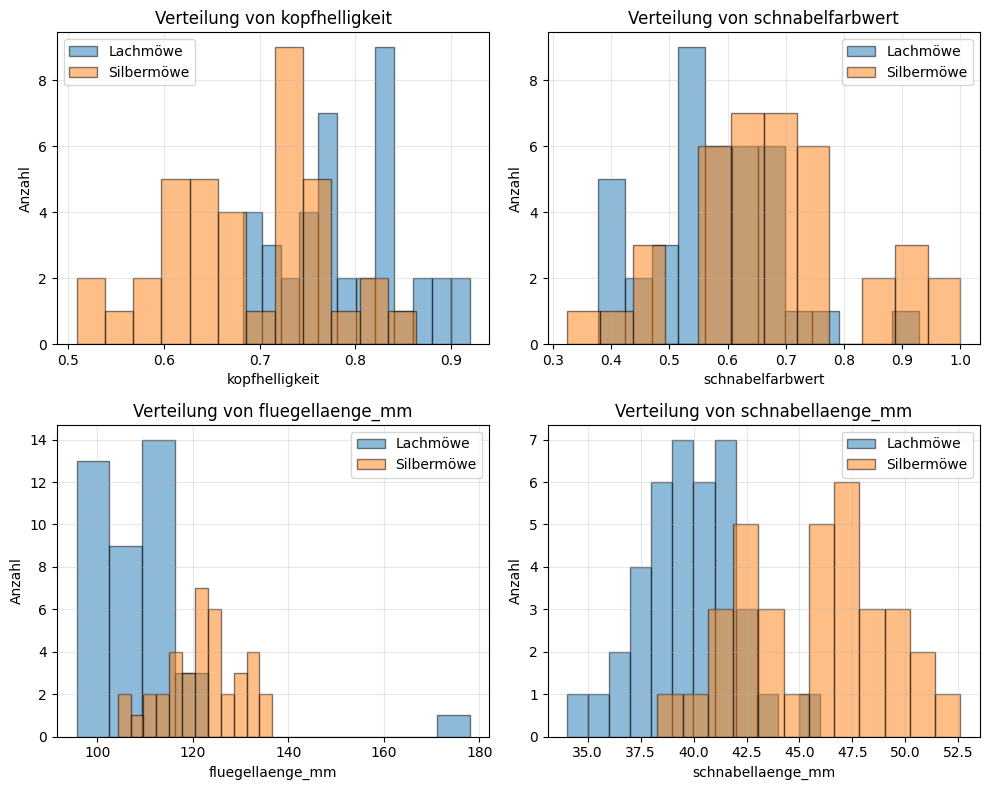

In [11]:
# Verteilung wichtiger numerischer Merkmale nach Art
import matplotlib.pyplot as plt

features = ["kopfhelligkeit", "schnabelfarbwert", "fluegellaenge_mm", "schnabellaenge_mm"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, feature in enumerate(features):
    ax = axes[i // 2, i % 2]
    for art in df["art"].dropna().unique():
        values = df[df["art"] == art][feature]
        ax.hist(values, bins=12, alpha=0.5, label=art, edgecolor="black")
    ax.set_title(f"Verteilung von {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Anzahl")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Visualisierung Kategorische Merkmale

> Kategorische Merkmale: Kategorische Merkmale sind nicht numerisch sondern beschreiben Kategorien, wie Fahrzeugmodelle bei VW (Golf, Jetta, Passat, ...) oder Straßennamen von Emden (Poststrasse) 

Einige Spalten in unserem Datensatz sind ebenfalls kategorisch, zum Beispiel:

- `schnabelfarbe`
- `kamera_id`
- `beobachtungsort`
- `art`

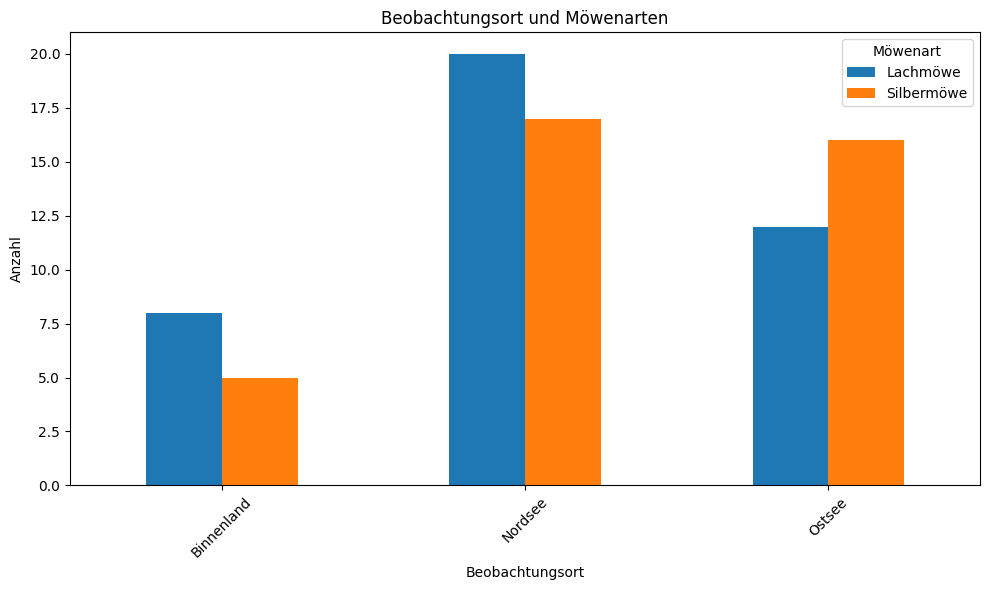

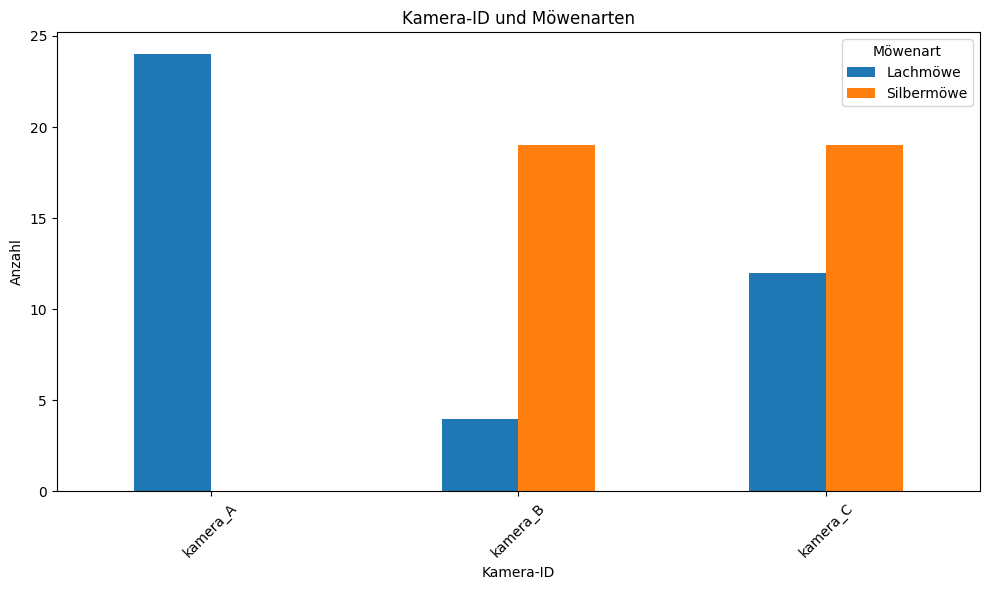

In [12]:
# Analyse kategorischer Variablen
# Ziel: verstehen, wie häufig bestimmte Kategorien vorkommen und ob sie mit der Zielklasse zusammenhängen.
import matplotlib.pyplot as plt
# Gruppierte Darstellung: Beobachtungsort vs. Möwenart
# Damit sehen wir, ob bestimmte Orte stärker mit bestimmten Arten zusammenhängen.
beobachtungsort_counts = df.groupby(["beobachtungsort", "art",]).size().unstack(fill_value=0)
beobachtungsort_counts.plot(kind="bar", figsize=(10, 6))
plt.title("Beobachtungsort und Möwenarten")
plt.xlabel("Beobachtungsort")
plt.ylabel("Anzahl")
plt.xticks(rotation=45)
plt.legend(title="Möwenart")
plt.tight_layout()
plt.show()

# Jetzt schauen wir mit welcher Kamera die meisten Bilder aufgenommen wurden und ob es eine Korrelation mit der Art gibt.
kamera_counts = df.groupby(["kamera_id", "art"]).size().unstack(fill_value=0)
kamera_counts.plot(kind="bar", figsize=(10, 6))
plt.title("Kamera-ID und Möwenarten")
plt.xlabel("Kamera-ID")
plt.ylabel("Anzahl")
plt.xticks(rotation=45)
plt.legend(title="Möwenart")
plt.tight_layout()
plt.show()


## Beobachtung aus der Visualisierung unserer kategorischen Merkmale

Kamera_A scheint ausschließlich Beobachtungen von Lachmöwen zu enthalten. Ggf. wurde die Kamera ausschließlich dort verwendet, wo Lachmöwen vorkommen oder der Beobachter hat sich ausschließlich auf Lachmöwen fokussiert. 

*Ist die Kamera ID ein Merkmal welches uns hilft die Möwenart zu klassifizieren?*


Damit wir mit diesen Merkmalen in unserem Modell arbeiten können müssen wir diese kategorischen Merkmale in für unser Modell interpretierbare Merkmale überführen. 


## 7. Daten bereinigen und vorbereiten
Vor dem Training müssen wir prüfen, ob fehlende Werte in den Merkmalen sowie unserer Zielvariable existieren. Zusätzlich müssen wir sicherstellen, dass Datenpunkte, denen wichtige Informationen fehlen, nicht unbeabsichtigt in das Training einfließen.

**Warum ist Bereinigung wichtig?**
Ein fehlender Wert kann den Algorithmus verwirren, weil er mathematisch keinen Sinn ergibt. Wenn Werte fehlen, kann das Modell nicht sauber zwischen Merkmalen und Ziel unterscheiden.

Wichtige Fragen:

- Welche Spalten enthalten NaN-Werte?
- Wie viele Beobachtungen bleiben nach dem Bereinigen übrig?
- Ist die Zielvariable `art` vollständig?

In vielen Projekten ist dieser Schritt der wichtigste, weil er die Qualität des späteren Modells deutlich beeinflusst. Selbst ein sehr guter Algorithmus kann mit schlechten Daten keine guten Vorhersagen liefern.

In [13]:
# Fehlende Werte prüfen
# Ziel: erkennen, welche Merkmale unvollständig sind und ob wir Zeilen entfernen müssen.
missing_values = df.isna().sum()
print("Fehlende Werte pro Spalte:")
print(missing_values[missing_values > 0])

# Auswahl der Spalten, die für das Training relevant sind
# Alle Zeilen mit fehlenden Werten in diesen Spalten werden entfernt.
feature_columns = [
    "kopfhelligkeit",
    "schnabelfarbwert",
    "fluegellaenge_mm",
    "schnabellaenge_mm",
    "beobachtungsort",
    "art",
]

# Zeilen mit fehlenden Werten entfernen
# Dieser Schritt ist wichtig, weil fehlende Werte das Modell sonst verwirren würden.
df_cleaned = df.dropna(subset=feature_columns).copy()
print(f"\nAnzahl der verbleibenden Zeilen: {len(df_cleaned)}")

Fehlende Werte pro Spalte:
art                  2
geschlecht           6
schnabelfarbe        3
schnabellaenge_mm    5
dtype: int64

Anzahl der verbleibenden Zeilen: 73


# 8. Zwischenfazit nach Datenanalyse, Vorverarbeitung und Datenbereinigung

Was haben wir bisher aus unserem Datensatz gelernt.

1. Nicht alle Merkmale des Rohdatensatzes lassen sich für die Klassifizierung nutzen (Pixelwerte)
2. Merkmale können unbeabsichtigt durch starke Korrelation die Zielvariable "leaken" 
3. Rohdaten können unvollständige Merkmalsvektoren $X$ enthalten oder die Zielvariable $y$ ist unbekannt. 

# 9. Datenvorbereitung - Aufteilung in Trainings- und Testdaten

Ein Modell lernt eine Entscheidungsgrenze für die Unterscheidung der Lach- und Silbermöwen aus den Merkmalsvektoren $X$. Um nach dem Trainingsprozess die Vorhersagequalität zu bewerten teilen wir zunächst die Daten in Trainings- und Testdaten auf. Typisch ist eine 80/20 Aufteilung in Trainings- und Testdaten.

*Warum machen wir diese Aufteilung in Trainings- und Testdaten?*

In [14]:
# 9. Datenvorbereitung - Aufteilung in Trainings- und Testdaten

from sklearn.model_selection import train_test_split

# Merkmale, die wir für die Klassifikation verwenden möchten
selected_features = [
    "kopfhelligkeit",
    "schnabelfarbwert",
    "fluegellaenge_mm",
    "schnabellaenge_mm",
    "schnabelfarbe",
    "beobachtungsort",
]

# Zielvariable
target = "art"

# Features X und Zielvariable y
X = df_cleaned[selected_features].copy()
y = df_cleaned[target].copy()

# Aufteilung in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# resample the training data to balance classes

print(f"Trainingsdaten: {len(X_train)} Zeilen")
print(f"Testdaten: {len(X_test)} Zeilen")

print("\nKlassenverteilung Training:")
print(y_train.value_counts())

print("\nKlassenverteilung Test:")
print(y_test.value_counts())

Trainingsdaten: 58 Zeilen
Testdaten: 15 Zeilen

Klassenverteilung Training:
art
Lachmöwe      31
Silbermöwe    27
Name: count, dtype: int64

Klassenverteilung Test:
art
Lachmöwe      8
Silbermöwe    7
Name: count, dtype: int64


## 10. Visualisierung der Klassenverteilung in den beiden Teildatensätzen

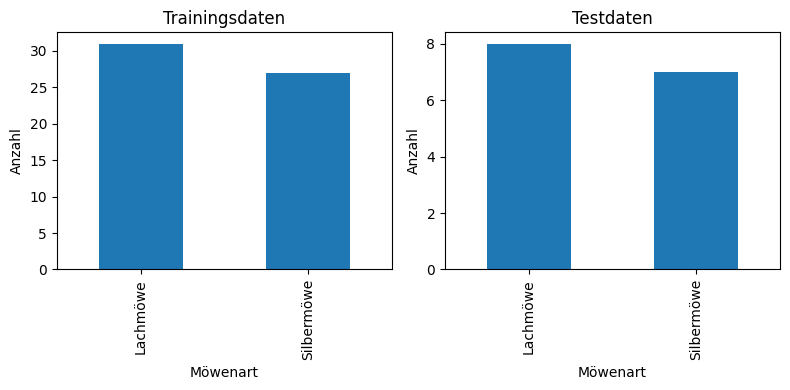

In [15]:
# 10. Visualisierung der Klassenverteilung

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
y_train.value_counts().plot(kind="bar")
plt.title("Trainingsdaten")
plt.xlabel("Möwenart")
plt.ylabel("Anzahl")

plt.subplot(1, 2, 2)
y_test.value_counts().plot(kind="bar")
plt.title("Testdaten")
plt.xlabel("Möwenart")
plt.ylabel("Anzahl")

plt.tight_layout()
plt.show()

> Was fällt auf wenn wir die Verteilung anschauen?

Im Trainingsdatensatz sind die Silbermöwen unterrepräsentiert. Das bedeutet der Datensatz ist nicht ausbalanciert.

In [16]:
## Resampling der Trainingsdaten zur Balancierung der Klassen

# Trainingsdaten wieder zu einem DataFrame zusammenführen
df_train_resampled = X_train.copy()
df_train_resampled["art"] = y_train.values

# Klassen zählen
class_counts = df_train_resampled["art"].value_counts()

print("Klassenverteilung vor Resampling:")
print(class_counts)

# Größe der Mehrheitsklasse
max_count = class_counts.max()

# Minderheitsklasse(n) hochsamplen
for class_name, count in class_counts.items():

    if count < max_count:

        samples_to_add = df_train_resampled[
            df_train_resampled["art"] == class_name
        ].sample(
            n=max_count - count,
            replace=True,
            random_state=42
        )

        df_train_resampled = pd.concat(
            [df_train_resampled, samples_to_add]
        )

# Datensatz mischen
df_train_resampled = df_train_resampled.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("\nKlassenverteilung nach Resampling:")
print(df_train_resampled["art"].value_counts())

# Features und Zielvariable wieder trennen

X_train = df_train_resampled.drop(columns="art")
y_train = df_train_resampled["art"]

print(f"\nTrainingsdaten nach Resampling: {len(X_train)}")
print(f"Testdaten unverändert:          {len(X_test)}")

Klassenverteilung vor Resampling:
art
Lachmöwe      31
Silbermöwe    27
Name: count, dtype: int64

Klassenverteilung nach Resampling:
art
Lachmöwe      31
Silbermöwe    31
Name: count, dtype: int64

Trainingsdaten nach Resampling: 62
Testdaten unverändert:          15


## 11. One-Hot Encoding Kategorische Merkmale


**Grundidee des One-Hot Encodings:**
Wir wandeln die Kategorien in einen Binär Vektor um und kodieren unsere kategorischen Merkmalen mit diesem Vektor.

Erklärung am Beispiel des Beobachtungsorts:

Das Merkmal Beobachtungsort enthält `Nordsee`, `Ostsee`, `Binnenland`. Aus diesen 3 Zuständen ergibt sich ein Binärvektor der Länge 3 und die Variabeln werden wie folgt enkodiert:
- `Nordsee` → [001]
- `Ostsee` → [010]
- `Binnenland` → [100]

In [17]:
# Kategorische Merkmale One-Hot-Encodieren

categorical_columns = [
    "schnabelfarbe",
    "beobachtungsort"
]

# Training codieren
X_train = pd.get_dummies(
    X_train,
    columns=categorical_columns,
    dtype=int
)

# Testdaten codieren
X_test = pd.get_dummies(
    X_test,
    columns=categorical_columns,
    dtype=int
)

# Sicherstellen, dass Training und Test exakt dieselben Features besitzen
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

print("Anzahl Features nach One-Hot-Encoding:")
print(f"Training: {X_train.shape[1]}")
print(f"Test:     {X_test.shape[1]}")

print("\nVerwendete Features:")
print(X_train.columns.tolist())

Anzahl Features nach One-Hot-Encoding:
Training: 10
Test:     10

Verwendete Features:
['kopfhelligkeit', 'schnabelfarbwert', 'fluegellaenge_mm', 'schnabellaenge_mm', 'schnabelfarbe_gelb', 'schnabelfarbe_orange', 'schnabelfarbe_rot', 'beobachtungsort_Binnenland', 'beobachtungsort_Nordsee', 'beobachtungsort_Ostsee']


## 12. Model Trainieren - Der Entscheidungsbaum

Wir haben unsere Rohdaten in ein strukturierten, für das Training eines Modelles geeigneten, Datensatz umgewandelt. Als finaler Schritt werden wir nun ein Entscheidungsbaum als Modell trainiert.


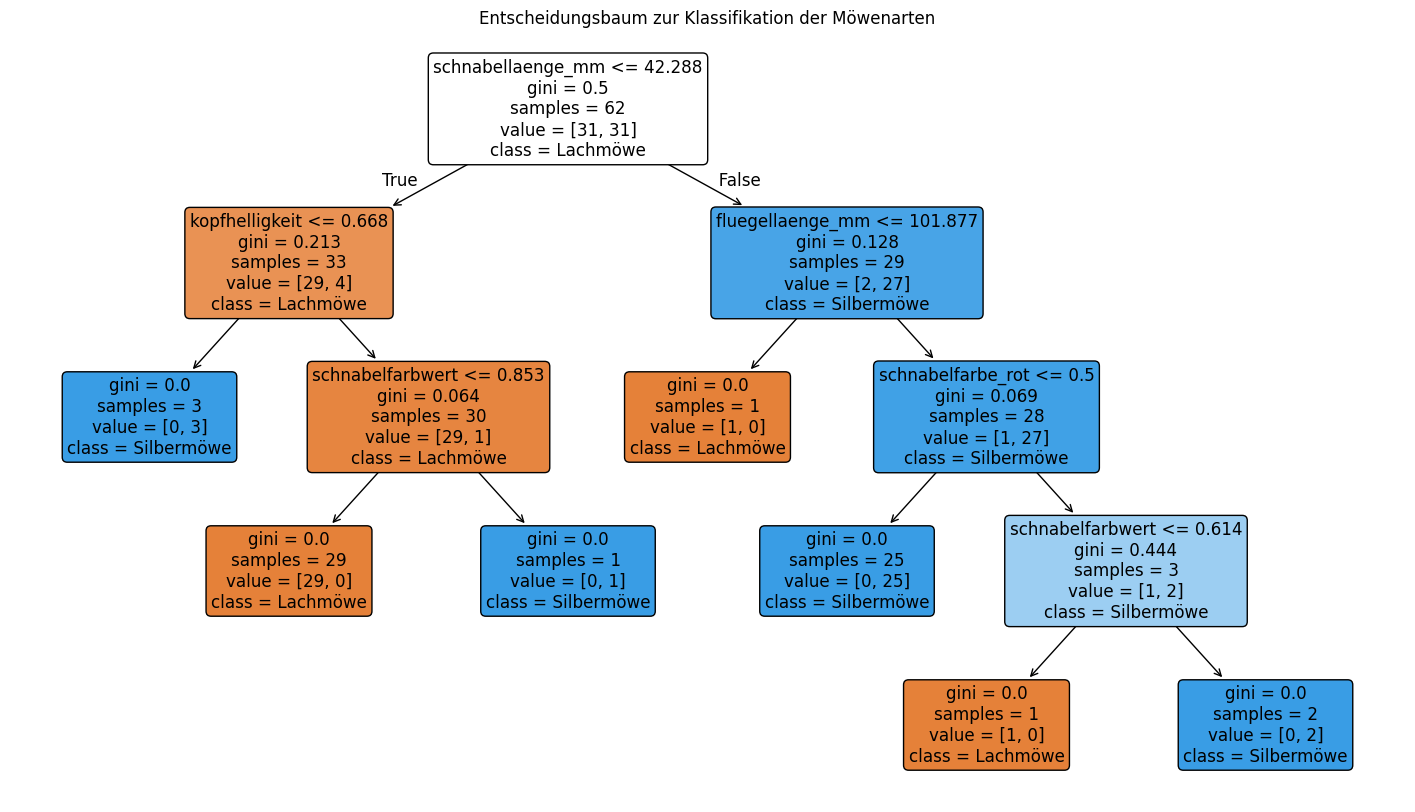



In [18]:
# 12. Modell trainieren - Entscheidungsbaum

from sklearn.tree import DecisionTreeClassifier

# Entscheidungsbaum erzeugen
tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Modell mit den Trainingsdaten trainieren
tree.fit(X_train, y_train)

print("Entscheidungsbaum wurde erfolgreich trainiert.")

Entscheidungsbaum wurde erfolgreich trainiert.


## 13. Modell evaluieren – Wie gut ist unser Modell?

Das Modell wurde mit den Trainingsdaten trainiert.

Jetzt kommt die entscheidende Frage:

> **Wie gut funktioniert das Modell auf Daten, die es während des Trainings noch nicht gesehen hat?**

Dafür verwenden wir die **Testdaten**.

Wir betrachten zunächst die Vorhersagen des Modells und vergleichen sie mit den tatsächlichen Labels.

1. Wie viele Beobachtungen werden korrekt klassifiziert?
2. Welche Fehler macht das Modell?
3. Werden beide Möwenarten ähnlich gut erkannt?


##  Accuracy – Wie viele Vorhersagen sind richtig?

Eine erste einfache Kennzahl ist die **Accuracy**.

Sie beantwortet die Frage:

> **Welcher Anteil aller Testbeispiele wurde korrekt klassifiziert?**

Formel:

$
Accuracy = \frac{\text{Anzahl korrekter Vorhersagen}}
{\text{Anzahl aller Vorhersagen}}
$

## Confusion Matrix – Welche Fehler macht das Modell?

Die Accuracy sagt uns nur, wie viele Vorhersagen insgesamt richtig waren.

Sie sagt uns aber nicht:

> **Welche Möwenart wird verwechselt?**

Die Confusion Matrix zeigt deshalb die Vorhersagen detaillierter.

Accuracy: 86.67%
Confusion Matrix:
[[6 2]
 [0 7]]


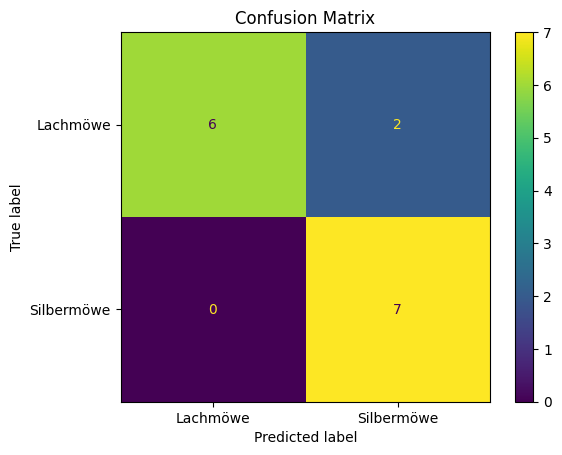

In [19]:
# Vorhersage auf den bisher ungesehenen Testdaten

y_pred = tree.predict(X_test)



from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=tree.classes_
).plot()

plt.title("Confusion Matrix")
plt.show()

# 14. Zusammenfassung und Fazit

Wir sind heute den Weg

> **vom Rohdatensatz zum trainierbaren Modell**

gegangen.

### Was haben wir dabei gemacht?

- **Daten verstanden:** Struktur, Merkmale und Klassenverteilung untersucht
- **Datenqualität geprüft:** fehlende und auffällige Werte betrachtet
- **Features ausgewählt:** fachlich sinnvolle Merkmale von ungeeigneten Merkmalen getrennt
- **Daten vorbereitet:** Trainings- und Testdaten getrennt und kategoriale Merkmale mit One-Hot-Encoding transformiert
- **Modell trainiert:** einen Entscheidungsbaum auf den Trainingsdaten gelernt
- **Modell bewertet:** die Vorhersagen auf bisher unbekannten Testdaten mit Accuracy und Confusion Matrix untersucht

### Die zentrale Erkenntnis

> **Die Qualität eines Machine-Learning-Modells hängt nicht nur vom Algorithmus ab.**
>
> **Die Qualität der Daten und die Art ihrer Vorbereitung sind genauso entscheidend.**

### Transfer in die Praxis

Bevor wir ein solches Modell in einem realen System einsetzen, würden wir unter anderem fragen:

> Sind die verwendeten Merkmale tatsächlich fachlich sinnvoll?

> Wie robust ist das Modell gegenüber neuen Daten?

> Wie zuverlässig ist unsere gemessene Modellleistung?

> Welche weiteren Daten oder Merkmale könnten das Modell verbessern?

**Damit beginnt Machine Learning nicht erst beim Training des Modells – sondern bereits bei der Vorbereitung der Daten.**